## Practice for Arrays and Hashing type problems

In [4]:
import time

## 1. Two Sum

#### Brute Force (Iterative/Exhaustive Search)

In [18]:
# Two Sum - #1 python 
# time complexity: O(n^2)
# space complexity: O(1) [because the algorithm performs its operations directly
# on the input array and does not require any additional data structures or memory allocation.]

def twoSum(nums, target):
    # start_time = time.time()

    for i in range(0, len(nums)):
        for j in range(i+1, len(nums)):
            if nums[i] + nums[j] == target:
                # end_time = time.time()
                # print("execution time: ", end_time - start_time, "seconds", "... indices: ", i, j)
                return [i, j]


twoSum([11, 15, 2, 7], 9)
# twoSum([1,2,3,4], 7)
# twoSum([1,2,3,4,9,10,6,11], 17)


[2, 3]

#### Can you come up with an algo that is less than $O(n^2)$? 

1. One-Pass Hash Map: time comp,: $O(n)$ (optimal), space comp.: $O(n)$ (because of the new data structure added [hash map] )
2. Two-Pointer Method time comp,: $O(n)$ (optimal), space comp.: $O(1)$ (only O(1) if the array is inputed to the function sorted... if not sorted the space complexity is $O(n *log n)$)


#### Hash Map solution **(considered the best method)**

In [19]:
# Two Sum - #1 One-Pass Hash Map method


def twoSum(nums, target):
    seen = {} # this maps value -> index
    for i, num in enumerate(nums): # for every index and value in nums
        complement = target - num
        if complement in seen:
            return [seen[complement], i]
        seen[num] = i # this will add all of the values in nums on the first run (unless the complement is found first)
                        # therefore, worst ase scenario is O(n)

twoSum([11, 15, 2, 7], 9)



[2, 3]

#### two pointer method

In [21]:
# array not sorted - Two Pointer method

def twoSum(nums, target):
    # Preserve original indices using enumerate: [(value, original_index), ...]
    indexed_nums = sorted([(num, i) for i, num in enumerate(nums)])

    left, right = 0, len(indexed_nums) - 1

    while left < right:
        current_sum = indexed_nums[left][0] + indexed_nums[right][0]

        if current_sum == target:
            # Return original stored indices
            return [indexed_nums[left][1], indexed_nums[right][1]]
        elif current_sum < target:
            left += 1
        else:
            right -= 1

twoSum([11, 15, 2, 7], 9)



[2, 3]

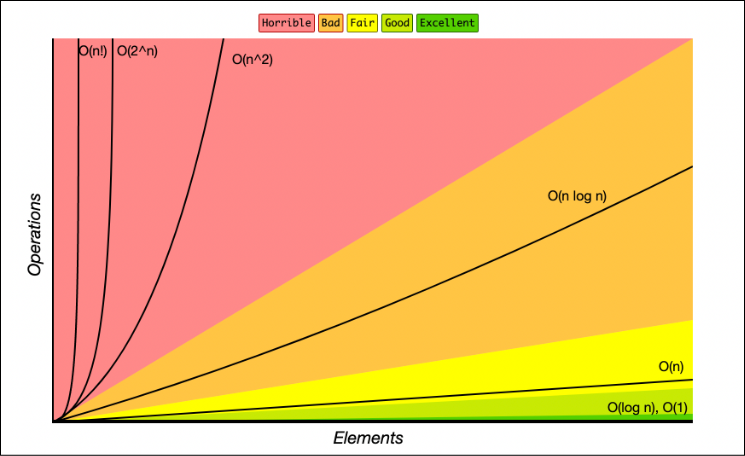

## 217. Contains Duplicate

In [27]:
# i immediate though to use a hash map
# TIME COMPLEXITY: O(n)
# SPACE COMPLEXITY: O(n)

def containsDuplicate(nums):
        """
        :type nums: List[int]
        :rtype: bool
        """
        seen = {}

        for num in nums:
            if num in seen:
                return True
            
            seen[num] = True

        return False

containsDuplicate([1,2,3,4,5,6,7,8,9,10]) # False
containsDuplicate([1,2,3,4,5,6,7,8,9,10,1]) # True

True

#### Optimal Solution: using a set

A <mark>set()</mark>  is preferred here because you only care about tracking unique values, not indices or mapping indices to values (key-value pairs)

*same time and space complexity as the hash map, though*

In [31]:
def containsDuplicate(nums):
        seen = set()

        for num in nums:
            if num in seen:
                return True
            seen.add(num)

        return False

containsDuplicate([1,2,3,4,5,6,7,8,9,10]) # False
containsDuplicate([1,2,3,4,5,6,7,8,9,10,1]) # True

True

## 219: Contain Duplicate II

In [34]:
# hash map method

def containsNearbyDuplicate(nums, k):
        """
        :type nums: List[int]
        :type k: int
        :rtype: bool
        """
        seen = {}

        for i, num in enumerate(nums):
            if (num in seen) and (abs(i-seen[num]) <= k):
                return True

            seen[num] = i
                
        return False

containsNearbyDuplicate([1,2,3,1], 3) # True


True

In [38]:
# Set() method / Windows method alternative

def containsNearbyDuplicate(nums, k):
        window = set()

        for i, num in enumerate(nums):
            if num in window:
                return True
            
            window.add(num)

            # Keep window size at most k
            if len(window) > k:
                window.remove(nums[i - k])

        return False

containsNearbyDuplicate([1,2,3,1], 3) # True

True

## 242. Valid Anagram

In [40]:
def isAnagram(s, t):
        if len(s) != len(t):
            return False

        count = {}

        # Increment counts for s, decrement for t
        for char in s:
            count[char] = count.get(char, 0) + 1

        for char in t:
            if char not in count or count[char] == 0:
                return False
            count[char] -= 1

        return True


# there are other versions with python, this was the least encapsulated version